In [1]:
import torch

In [2]:
class LinearLayer:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.weights = (torch.randn((input_dim, output_dim), dtype=torch.float64) / (input_dim ** 0.5)).requires_grad_(True)
        self.biases = (torch.randn((1, output_dim), dtype=torch.float64)/ (input_dim ** 0.5 )).requires_grad_(True)

    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D); weights: (D,LD); Biases: (1,LD)
        output = inputs @ self.weights + self.biases
        return output

    def get_params(self):
        return [self.weights, self.biases]

layer = LinearLayer(5,10)
print(layer.weights.shape)
print(layer.biases.shape)
print(layer.forward(torch.rand((12,5), dtype=torch.float64)).shape)
print(layer.weights.requires_grad)

torch.Size([5, 10])
torch.Size([1, 10])
torch.Size([12, 10])
True


In [3]:
class LeakyReLU:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
    
    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D)
        mask = inputs<0
        return torch.where(mask, self.alpha*inputs, inputs)


relu = LeakyReLU(alpha=0.01)
print(relu(torch.tensor([[-1,2,-2]])))

tensor([[-0.0100,  2.0000, -0.0200]])


In [4]:
class Model:
    def __init__(self, input_dim, output_dim, hidden_dim):
        self.input_layer = LinearLayer(input_dim, hidden_dim)
        self.hidden_layer = LinearLayer(hidden_dim, hidden_dim)
        self.output_layer = LinearLayer(hidden_dim, output_dim)

        self.leaky_relu = LeakyReLU()

    def __call__(self, inputs):
        return self.forward(inputs)

    def forward(self, inputs):
        #inputs: (B, D);

        output = self.leaky_relu(self.input_layer(inputs))  #(B, HD)
        output = self.leaky_relu(self.hidden_layer(output)) #(B, HD)
        output = self.output_layer(output) #(B, OD)
        return output

    def get_params(self):
        return self.input_layer.get_params() + self.hidden_layer.get_params() + self.output_layer.get_params()

model = Model(3,2,5)
model(torch.rand((10,3), dtype=torch.float64)).shape

torch.Size([10, 2])

In [5]:
class MSE:
    def __init__(self):
        pass

    def __call__(self, gt, pred):
        return self.calculate_loss(gt, pred)
    
    def calculate_loss(self, ground_truth, predicted):
        #(B, D)
        return torch.mean((ground_truth-predicted)**2)


mse = MSE()
mse(torch.tensor([1.,2,3]), torch.tensor([1.,2,5]))

tensor(1.3333)

In [6]:
class GradientDescent:
    def __init__(self, params, alpha):
        self.params = params
        self.alpha = alpha

    def step(self):
        with torch.no_grad():
            for param in self.params:
                if(param.grad is not None):
                    param -= self.alpha * param.grad

    def zero_grad(self):
        for param in self.params:
            if(param.grad is not None):
                param.grad.zero_()
        

In [7]:
from torch.utils.data import DataLoader, Dataset

class SimpleDataset(Dataset):

    def __init__(self, x: torch.Tensor, y: torch.Tensor):
        self.x = x
        self.y = y

    def __len__(self) -> int:
        return len(self.x)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return (self.x[idx], self.y[idx])

torch.Size([1000, 2])


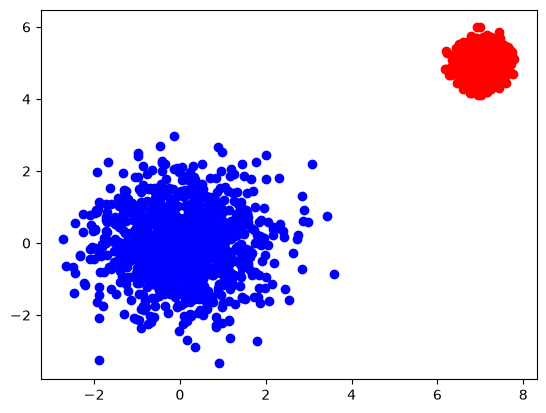

In [8]:
import matplotlib.pyplot as plt

torch.manual_seed(42)

x = torch.randn(1000, 2, dtype=torch.float64)
print(x.shape)
plt.scatter(x[:,0:1], x[:,1:], color="blue")


y = torch.randn(1000, 2, dtype=torch.float64)*0.3 + torch.tensor([[7, 5]])
.0
plt.scatter(y[:,0:1], y[:,1:], color="red")
plt.show()


In [9]:
y_mean = torch.mean(y, dim=0)
print(y_mean.shape)

y_std = torch.std(y, dim=0)
print(y_std.shape)

y_norm = (y - y_mean)/y_std
print(torch.std(y_norm))

data = SimpleDataset(x, y)
data[0]

torch.Size([2])
torch.Size([2])
tensor(0.9997, dtype=torch.float64)


(tensor([0.2996, 0.2424], dtype=torch.float64),
 tensor([7.5523, 4.4736], dtype=torch.float64))

100%|██████████| 500/500 [00:11<00:00, 43.08it/s]


Final loss: 0.5009572505950928


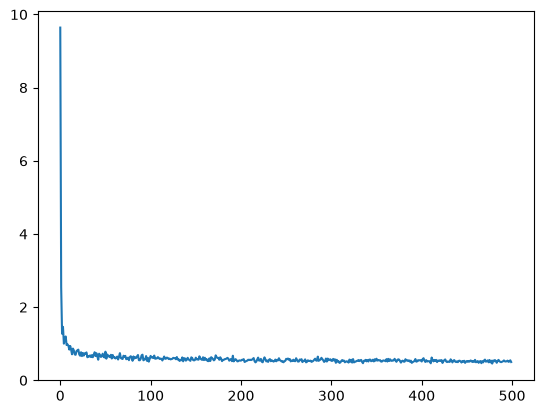

In [10]:
from tqdm import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(34)

EPOCHS = 500
BATCH_SIZE = 32

data_loader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True)
velocity_field = Model(3, 2, 10)

loss_function = MSE()
optimizer = GradientDescent(params = velocity_field.get_params(), alpha = 0.01)

loss_log = []

for i in tqdm(range(EPOCHS)):
    losses = []
    for _, goal_pos in data_loader:
        noise = torch.randn(goal_pos.shape)                 #(B, 2)
        t = torch.rand((noise.shape[0],1))                  #(B, 1)
        starting_points = noise*(1-t) + goal_pos*t          #(B, 2)

        inputs = torch.concat((starting_points, t), dim=-1) #(B, 3)
        pred_vel = velocity_field(inputs)                   #(B, 2)
        target_vel = goal_pos - noise                       #(B, 2)
        loss = loss_function(pred_vel, target_vel)          # Scaler
        losses.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_log.append(torch.mean(torch.tensor(losses)))

final_loss = loss_log[-1]
plt.plot(loss_log)
print(f"Final loss: {final_loss}")


100%|██████████| 10/10 [00:00<00:00, 1223.90it/s]


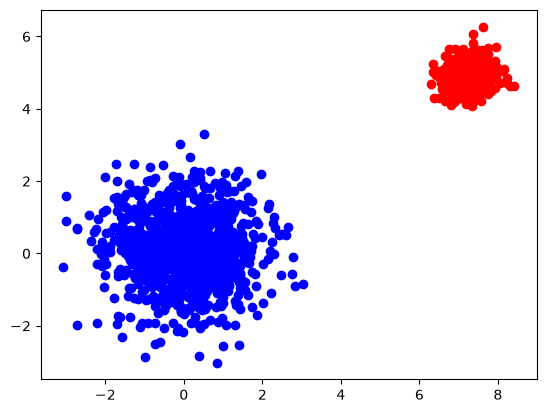

In [11]:
import matplotlib.pyplot as plt

torch.manual_seed(15)

INFERENCE_STEPS = 10


x_eval = torch.randn(1000,2 , dtype=torch.float64)
time_interval = 1/INFERENCE_STEPS

x_curr = x_eval.clone()                                       # (B,2)

with torch.no_grad():
    for i in tqdm(range(INFERENCE_STEPS)):
        t = torch.ones((x_eval.shape[0], 1))*i*time_interval  # (B,1)
        inputs = torch.concat((x_curr, t), dim=-1)            # (B,3)
        vel = velocity_field(inputs)                          # (B,2)
        x_curr += vel*time_interval                           # (B,2)


plt.scatter(x_eval[:,0:1], x_eval[:,1:], color="blue")
plt.scatter(x_curr[:,0:1], x_curr[:,1:], color="red")



In [12]:
print(torch.mean(x_curr, dim=0))
print(torch.std(x_curr, dim=0))

tensor([7.1777, 4.8570], dtype=torch.float64)
tensor([0.2946, 0.2689], dtype=torch.float64)
